<a href="https://colab.research.google.com/github/moralesalessandra29-crypto/LABORATORIO-DE-PDI/blob/main/P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 4 - Procesamiento Digital de Imágenes**

* 2055762 Alondra María Cruz Castillo
* 2063509 Alessandra Morales Vázquez

**Parte I.- Procesamiento geométrico**

Ejercicio 1: Traslación

In [ ]:
# Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
# Cargar la imagen en escala de grises
ruta = "/content/drive/MyDrive/PDI/Xray.jpg"

img = cv2.imread(ruta)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rows, cols = img_gray.shape[:2]

In [ ]:
# Aplicar traslación (50, 30) píxeles
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
img_trans1 = cv2.warpAffine(img_gray, M_trans, (cols, rows))

In [ ]:
# Aplicar traslación (20.5, 15.5) píxeles
M_trans = np.float32([[1, 0, 20.5], [0, 1, 15.5]])
img_trans2 = cv2.warpAffine(img_gray, M_trans, (cols, rows))

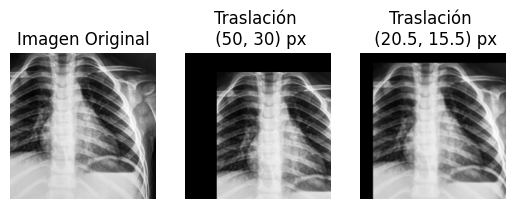

In [ ]:
# Mostrar imágenes
plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_trans1, cmap='gray')
plt.title('Traslación \n (50, 30) px')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_trans2, cmap='gray')
plt.title('Traslación \n (20.5, 15.5) px')
plt.axis('off')

plt.show()

Ejercicio 2: Rotación

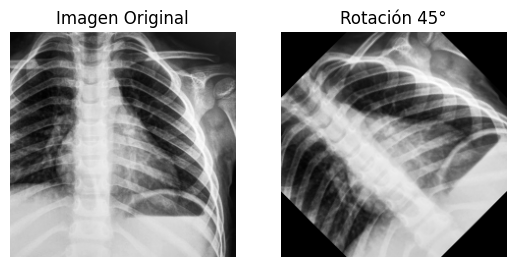

In [ ]:
# Rotación 45° alrededor del centro de la imagen
M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
img_rot = cv2.warpAffine(img_gray, M_rot, (cols, rows))

# Mostrar imágenes
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_rot, cmap='gray')
plt.title('Rotación 45°')
plt.axis('off')

plt.show()

Ejercicio 3: Escalado

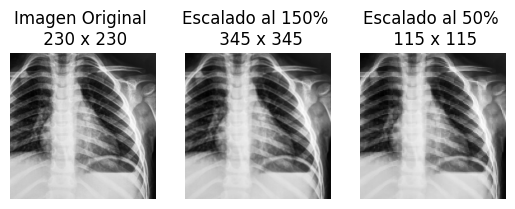

In [ ]:
# Escala orginal
escala = 1
ancho = int(img_gray.shape[1] * escala)
alto = int(img_gray.shape[0] * escala)

# Escalado al 150%
escala = 1.5
ancho_150 = int(img_gray.shape[1] * escala)
alto_150 = int(img_gray.shape[0] * escala)
img_150 = cv2.resize(img_gray, (ancho_150, alto_150), interpolation=cv2.INTER_LINEAR)

# Escalado al 50%
escala = 0.5
ancho_50 = int(img_gray.shape[1] * escala)
alto_50 = int(img_gray.shape[0] * escala)
img_50 = cv2.resize(img_gray, (ancho_50, alto_50), interpolation=cv2.INTER_LINEAR)

# Mostrar imágenes
plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title(f'Imagen Original \n {ancho} x {alto}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_150, cmap='gray')
plt.title(f'Escalado al 150% \n {ancho_150} x {alto_150}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_50, cmap='gray')
plt.title(f'Escalado al 50% \n {ancho_50} x {alto_50}')
plt.axis('off')

plt.show()

**Parte II.- Ecualización de histograma**

Ejercicio 1: Ecualización

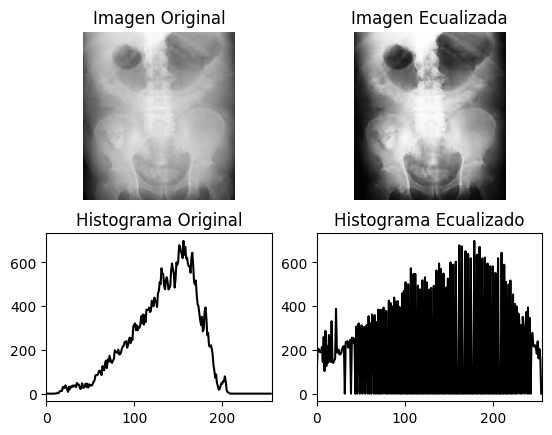

In [ ]:
# Cargar imagen
ruta2 = "/content/drive/MyDrive/PDI/radiografía.jpg"
img2 = cv2.imread(ruta2)
img_gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Histograma de imagen original
hist_original = cv2.calcHist([img_gray2], [0], None, [256], [0, 255])
bins = np.arange(256)

# Ecualización de histograma
ecua = cv2.equalizeHist(img_gray2)

#Histograma ecualizado
hist_ecualizado = cv2.calcHist([ecua], [0], None, [256], [0, 255])
bins = np.arange(256)

# Mostrar imágenes
plt.subplot(2,2,1)
plt.imshow(img_gray2, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(ecua, cmap='gray')
plt.title('Imagen Ecualizada')
plt.axis('off')

# Mostrar histogramas
plt.subplot(2,2,3)
plt.plot(bins, hist_original, color='black')
plt.title('Histograma Original')
plt.xlim([0,256])

plt.subplot(2,2,4)
plt.plot(bins, hist_ecualizado, color='black')
plt.title('Histograma Ecualizado')
plt.xlim([0,256])

plt.show()